# Learning an Unknown Nonlinear Function via Neural Sub-expression

## Soil Carbon with Unknown Moisture Response

Instead of learning a scalar parameter, we learn an **entire unknown function** using a neural network, then decompile it back to symbolic form.

**Model:**
```
C(n+1) = C(n) - k · f_moisture(M) · C(n) · dt
```

- `k` = base decomposition rate (**known**)
- `f_moisture(M)` = moisture response function (**unknown** — learned as MLP)
- Ground truth: `f_moisture(m) = m^0.7 / (0.3 + m^0.7)` (Hill equation)

After training, symbolic regression on the MLP recovers the Hill equation.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from cajal.syntax import TmIter, TmVar, TmApp, TyNat, TyBool, TyReal
from cajal.compiling import compile, TypedTensor

# CPU is faster for this workload (many tiny sequential ops)
device = torch.device("cpu")

K_BASE = 0.5
DT = 0.1
C0 = 1.0
N_STEPS = 10
N_TRAJ  = 20

def true_f_moisture(m):
    return m ** 0.7 / (0.3 + m ** 0.7)

moistures = torch.linspace(0.05, 1.0, N_TRAJ)
all_curves = []
for m in moistures:
    f_m = true_f_moisture(m)
    curve = []
    c = C0
    for _ in range(N_STEPS):
        curve.append(c)
        c = c * (1.0 - K_BASE * f_m * DT)
    all_curves.append(torch.tensor(curve))

print(f"Generated {N_TRAJ} training trajectories at different moisture levels")
print(f"True f_moisture: Hill equation m^0.7 / (0.3 + m^0.7)")

Generated 20 training trajectories at different moisture levels
True f_moisture: Hill equation m^0.7 / (0.3 + m^0.7)


In [2]:
class MoistureResponseMLP(nn.Module):
    """f_moisture: R -> [0,1].  Sigmoid output is a structural constraint."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1), nn.Sigmoid(),
        )
    def forward(self, m):
        return self.net(m.view(1, 1)).squeeze()

class DecayWithMoisture(nn.Module):
    def __init__(self, k, dt, mlp):
        super().__init__()
        self.k, self.dt, self.f_moisture = k, dt, mlp
    def forward(self, state):
        c = state.data[0]
        moisture = state.data[1]
        f_m = self.f_moisture(moisture)
        c_new = c - self.k * f_m * c * self.dt
        return TypedTensor(torch.stack([c_new, moisture]), state.ty)

program  = TmIter(TmVar("s0"), "s", TmApp(TmVar("f"), TmVar("s")), TmVar("n"))
compiled = compile(program)

mlp       = MoistureResponseMLP()
update_fn = DecayWithMoisture(K_BASE, DT, mlp)
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.005)
n_params  = sum(p.numel() for p in mlp.parameters())
print(f"MLP has {n_params} parameters")

losses = []
for epoch in range(800):
    optimizer.zero_grad()
    total_loss = torch.tensor(0.0)
    for traj_idx in range(N_TRAJ):
        m = moistures[traj_idx]
        s0 = TypedTensor(torch.stack([torch.tensor(C0), m]), TyReal(2))
        for step in range(N_STEPS):
            n_onehot = torch.zeros(N_STEPS)
            n_onehot[step] = 1.0
            n_val = TypedTensor(n_onehot, TyNat())
            result = compiled({"s0": s0, "f": lambda s, _fn=update_fn: _fn(s), "n": n_val})
            total_loss = total_loss + (result.data[0] - all_curves[traj_idx][step]) ** 2
    total_loss.backward()
    optimizer.step()
    losses.append(total_loss.item())
    if (epoch + 1) % 200 == 0:
        print(f"  epoch {epoch+1:3d}  loss={total_loss.item():.8f}")

MLP has 1153 parameters


  epoch 200  loss=0.00493772


  epoch 400  loss=0.00107890


  epoch 600  loss=0.00035698


  epoch 800  loss=0.00018694


In [3]:
# Evaluate learned function
test_m = torch.linspace(0.05, 1.0, 50)
with torch.no_grad():
    true_vals   = [true_f_moisture(m).item() for m in test_m]
    learned_vals = [mlp(m).item() for m in test_m]

max_err = max(abs(t - l) for t, l in zip(true_vals, learned_vals))
print(f"Max absolute error: {max_err:.4f}")

# Symbolic regression
m_grid = torch.linspace(0.01, 1.5, 200)
with torch.no_grad():
    y_learned = torch.tensor([mlp(m).item() for m in m_grid])

K_grid = torch.linspace(0.01, 2.0, 200)
candidates = {
    "MM: m/(K+m)":           lambda m, K: m / (K + m),
    "Hill n=0.5: m^0.5/(K+m^0.5)": lambda m, K: m**0.5 / (K + m**0.5),
    "Hill n=0.7: m^0.7/(K+m^0.7)": lambda m, K: m**0.7 / (K + m**0.7),
    "Hill n=1.5: m^1.5/(K+m^1.5)": lambda m, K: m**1.5 / (K + m**1.5),
    "quadratic: m^2/(K+m^2)": lambda m, K: m**2 / (K + m**2),
}

best_name, best_loss, best_K = None, float('inf'), None
sym_results = {}
for name, func in candidates.items():
    best_K_this, best_L_this = None, float('inf')
    for Kv in K_grid:
        pred = func(m_grid, Kv)
        L = ((pred - y_learned) ** 2).mean().item()
        if L < best_L_this:
            best_L_this, best_K_this = L, Kv.item()
    sym_results[name] = (best_L_this, best_K_this)
    if best_L_this < best_loss:
        best_loss, best_name, best_K = best_L_this, name, best_K_this

print()
print("Symbolic regression:")
for name, (L, K) in sym_results.items():
    marker = " <-- BEST" if name == best_name else ""
    print(f"  {name:40s}  MSE={L:.6f}  K={K:.3f}{marker}")
print(f"\nGround truth: Hill n=0.7, K=0.300")

Max absolute error: 0.0110

Symbolic regression:
  MM: m/(K+m)                               MSE=0.002556  K=0.240
  Hill n=0.5: m^0.5/(K+m^0.5)               MSE=0.001331  K=0.340
  Hill n=0.7: m^0.7/(K+m^0.7)               MSE=0.000145  K=0.300 <-- BEST
  Hill n=1.5: m^1.5/(K+m^1.5)               MSE=0.011968  K=0.160
  quadratic: m^2/(K+m^2)                    MSE=0.023105  K=0.100

Ground truth: Hill n=0.7, K=0.300


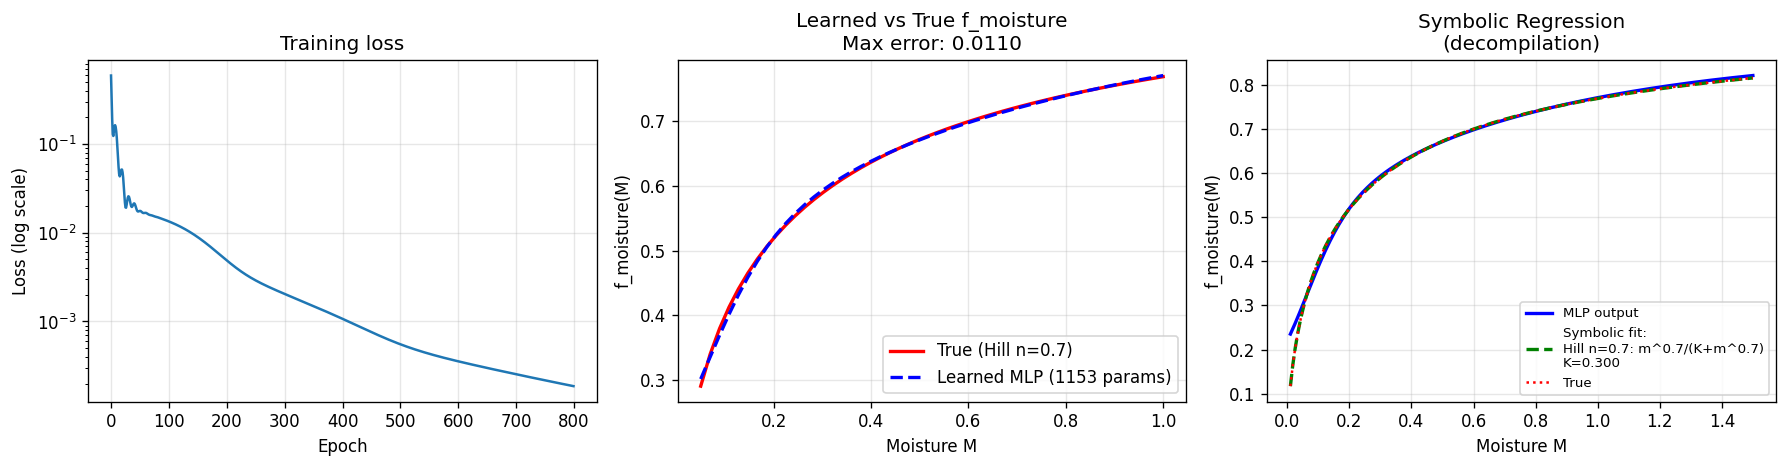

✓ Symbolic regression correctly recovered the Hill equation with n=0.7


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].semilogy(losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Training loss')
axes[0].grid(True, alpha=0.3)

# Learned vs true function
axes[1].plot(test_m.numpy(), true_vals, 'r-', linewidth=2, label='True (Hill n=0.7)')
axes[1].plot(test_m.numpy(), learned_vals, 'b--', linewidth=2, label=f'Learned MLP ({n_params} params)')
axes[1].set_xlabel('Moisture M')
axes[1].set_ylabel('f_moisture(M)')
axes[1].set_title(f'Learned vs True f_moisture\nMax error: {max_err:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Symbolic regression fit
best_func = candidates[best_name]
y_sym = best_func(m_grid, best_K)
axes[2].plot(m_grid.numpy(), y_learned.numpy(), 'b-', linewidth=2, label='MLP output')
axes[2].plot(m_grid.numpy(), y_sym.numpy(), 'g--', linewidth=2, label=f'Symbolic fit:\n{best_name}\nK={best_K:.3f}')
axes[2].plot(m_grid.numpy(), [true_f_moisture(m).item() for m in m_grid], 
             'r:', linewidth=1.5, label='True')
axes[2].set_xlabel('Moisture M')
axes[2].set_ylabel('f_moisture(M)')
axes[2].set_title('Symbolic Regression\n(decompilation)')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learn_unknown_function.png', dpi=120, bbox_inches='tight')
plt.show()

if '0.7' in best_name:
    print("✓ Symbolic regression correctly recovered the Hill equation with n=0.7")